# 🌿📱 HPDC-Net: Edge Device-Friendly CNN for Plant Leaf Disease Classification 🌾🧠

Welcome to the **HPDC-Net** 👨‍🔬🧪  
A **High-Performance Disease Classification Network (HPDC-Net)** designed for real-time, on-device plant disease detection using leaf images.  

---

## 🌟 Key Features of HPDC-Net

🔹 **Lightweight Architecture** – Perfect for edge deployment on mobile or IoT devices (Raspberry Pi, Jetson Nano).  
🔹 **High Accuracy** – Designed for robust performance on small datasets of plant leaf images.  
🔹 **Optimized Inference** – Fast and efficient with low memory and power usage.  
🔹 **Smart Feature Extraction** – Includes novel modules for capturing disease-specific patterns in leaf texture and color.  




## 📂 Dataset Loading and Preparation 🌿🧪

In this section, we will load and prepare the **Plant Leaf Disease Dataset** for training and evaluation using **PyTorch**. The dataset includes multiple classes such as healthy and diseased leaves from various crops. 🍅🍇🌾


In [1]:
!wget "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"

--2026-09-05 22:25:02--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d29ed9b2-8a5d-4663-8a82-c9174f2c7066 [following]
--2026-09-05 22:25:03--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d29ed9b2-8a5d-4663-8a82-c9174f2c7066
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.74.119, 52.92.19.26, 3.5.73.59, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.74.119|:443... conn

In [2]:
!unzip "/content/file_downloaded";

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_without_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/i

In [3]:
# import shutil
# shutil.rmtree('tomato')

In [4]:
import os
import shutil

# Define the directory containing the folders
directory = "/content/Plant_leave_diseases_dataset_without_augmentation"

# Get a list of all folders in the directory
folders = [
    f for f in os.listdir(directory) if os.path.isdir(os.path.join(directory, f))
]

# Iterate through the folders and delete those that do not contain "tomato" in their title
for folder in folders:
    if "tomato" not in folder.lower():
        folder_path = os.path.join(directory, folder)
        print(f"Deleting folder: {folder_path}")
        shutil.rmtree(folder_path)

Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Raspberry___healthy
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Squash___Powdery_mildew
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Grape___Black_rot
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Background_without_leaves
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Apple___Black_rot
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Grape___healthy
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Corn___healthy
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Blueberry___healthy
Deleting folder: /content/Plant_leave_diseases_dataset_without_augmentation/Peach___healthy
Deleting folder: /content/Plant_leave_d

In [5]:
#split dataset
!pip install split_folders
import splitfolders

base_dir = '/content/Plant_leave_diseases_dataset_without_augmentation'
splitfolders.ratio(base_dir, output='/content/tomato', seed = 1314, ratio = (.7, .2, .1))

train_dir = os.path.join('/content/tomato', 'train')
validation_dir = os.path.join('/content/tomato', 'val')
test_dir = os.path.join('/content/tomato', 'test')

Copying files: 18160 files [00:04, 4290.48 files/s]


In [6]:
import os
import random
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Function to set seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


# Set seed
seed = 42
set_seed(seed)

# Define the root directory of the dataset
data_dir = "/content/tomato"

# Define transformations for training, validation, and testing sets
train_transforms = transforms.Compose(
    [
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

valid_test_transforms = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Load datasets with ImageFolder
train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "train"), transform=train_transforms
)
valid_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "val"), transform=valid_test_transforms
)
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"), transform=valid_test_transforms
)

# Define data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the number of classes
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Class names: {train_dataset.classes}")

Number of classes: 10
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [7]:
!pip install thop

🌱🧠 **HPDCNet** is a lightweight convolutional neural network that combines depthwise adaptive residuals, hybrid pooling, and conditional feature enhancement. Designed for efficient and robust visual recognition, it fuses multi-scale features with recalibrated attention for superior performance.
### 🔬 Potential Applications:

✅ Smart Farming  
✅ Mobile Disease Detection Apps  
✅ Precision Agriculture  
✅ Drone Crop Monitoring  


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Block Definitions ---

class DepthwiseAdaptiveResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseAdaptiveResidualBlock, self).__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=3, stride=stride, padding=1, groups=in_channels
        )
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return F.relu(x + identity)


class ECABlock(nn.Module):
    def __init__(self, kernel_size=3):
        super(ECABlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class MultiScaleFusionBlock(nn.Module):
    def __init__(self, in_channels):
        super(MultiScaleFusionBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels, in_channels, kernel_size=5, padding=2)

    def forward(self, x):
        x1 = self.conv1(x)
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        return x1 + x3 + x5


class HybridPoolingLayer(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super(HybridPoolingLayer, self).__init__()
        self.max_pool = nn.MaxPool2d(kernel_size, stride)
        self.avg_pool = nn.AvgPool2d(kernel_size, stride)

    def forward(self, x):
        max_pooled = self.max_pool(x)
        avg_pooled = self.avg_pool(x)
        return (max_pooled + avg_pooled) / 2


class ConditionalFeatureEnhancement(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ConditionalFeatureEnhancement, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        weights = self.global_avg_pool(x).view(b, c)
        weights = F.relu(self.fc1(weights))
        weights = torch.sigmoid(self.fc2(weights)).view(b, c, 1, 1)
        return x * weights


# --- HPDC-Net ---

class HPDCNet(nn.Module):
    def __init__(self, num_classes=10):
        super(HPDCNet, self).__init__()
        # Stage 1
        self.layer1 = DepthwiseAdaptiveResidualBlock(3, 16)
        self.attn1 = ECABlock()
        self.pool1 = HybridPoolingLayer()

        # Stage 2
        self.layer2 = DepthwiseAdaptiveResidualBlock(16, 32)
        self.attn2 = ECABlock()
        self.pool2 = HybridPoolingLayer()

        # Stage 3
        self.layer3 = DepthwiseAdaptiveResidualBlock(32, 64)
        self.fusion3 = MultiScaleFusionBlock(64)
        self.attn3 = ECABlock()
        self.pool3 = HybridPoolingLayer()

        # Stage 4
        self.layer4 = DepthwiseAdaptiveResidualBlock(64, 128)
        self.fusion4 = MultiScaleFusionBlock(128)
        self.attn4 = ECABlock()

        # Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Stage 1
        x = self.layer1(x)
        x = self.attn1(x)
        x = self.pool1(x)

        # Stage 2
        x = self.layer2(x)
        x = self.attn2(x)
        x = self.pool2(x)

        # Stage 3
        x = self.layer3(x)
        x = self.fusion3(x)
        x = self.attn3(x)
        x = self.pool3(x)

        # Stage 4
        x = self.layer4(x)
        x = self.fusion4(x)
        x = self.attn4(x)

        # Classifier
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# Model Summary
if __name__ == "__main__":
    model = HPDCNet(num_classes=3)
    sample_input = torch.randn(1, 3, 224, 224)
    output = model(sample_input)
    print("Output shape:", output.shape)
    print("Model Summary:")
    from thop import profile

    flops, params = profile(model, inputs=(sample_input,))
    print(f"GFLOPs: {flops / 1e9:.2f}")
    print(f"Number of parameters (in millions): {params / 1e6:.2f}")

Output shape: torch.Size([1, 3])
Model Summary:
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_avgpool() for <class 'torch.nn.modules.pooling.AvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
GFLOPs: 0.96
Number of parameters (in millions): 0.74


In [9]:
!pip install tqdm torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.7 MB/s eta 0:00:00


### 🏋️ Model Training Procedure

The `HPDCNet` model was trained for 200 epochs using the Adam optimizer with a learning rate of `0.001` and CrossEntropyLoss.  
Training and validation were conducted on a multi-class classification task with 10 classes.

**Training Pipeline:**
- Device: GPU
- Data: Loaded via `train_loader` and `valid_loader`
- Metrics: Accuracy, Precision, Recall, and F1 Score (macro average using TorchMetrics)
- Best model checkpoint saved based on highest validation accuracy


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import torchmetrics

# Assume the dataset and data loaders are already defined
# Example:
# train_loader = ...
# valid_loader = ...

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model
num_classes = 10  # Example number of classes
model = HPDCNet(num_classes).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and validation loop
num_epochs = 100

# Metrics
train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(
    device
)
train_precision = torchmetrics.Precision(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
train_recall = torchmetrics.Recall(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
train_f1_score = torchmetrics.F1Score(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)

valid_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(
    device
)
valid_precision = torchmetrics.Precision(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
valid_recall = torchmetrics.Recall(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
valid_f1_score = torchmetrics.F1Score(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)

# Variable to track the best validation accuracy
best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    train_accuracy.reset()
    train_precision.reset()
    train_recall.reset()
    train_f1_score.reset()

    for inputs, labels in tqdm(
        train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"
    ):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_accuracy.update(outputs, labels)
        train_precision.update(outputs, labels)
        train_recall.update(outputs, labels)
        train_f1_score.update(outputs, labels)

    train_loss /= len(train_loader.dataset)
    train_accuracy_value = train_accuracy.compute().item()
    train_precision_value = train_precision.compute().item()
    train_recall_value = train_recall.compute().item()
    train_f1_value = train_f1_score.compute().item()

    # Validation
    model.eval()
    valid_loss = 0
    valid_accuracy.reset()
    valid_precision.reset()
    valid_recall.reset()
    valid_f1_score.reset()

    with torch.no_grad():
        for inputs, labels in tqdm(
            valid_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}"
        ):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * inputs.size(0)
            valid_accuracy.update(outputs, labels)
            valid_precision.update(outputs, labels)
            valid_recall.update(outputs, labels)
            valid_f1_score.update(outputs, labels)

    valid_loss /= len(valid_loader.dataset)
    valid_accuracy_value = valid_accuracy.compute().item()
    valid_precision_value = valid_precision.compute().item()
    valid_recall_value = valid_recall.compute().item()
    valid_f1_value = valid_f1_score.compute().item()

    # Save the model if validation accuracy improves
    if valid_accuracy_value > best_val_accuracy:
        best_val_accuracy = valid_accuracy_value
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(
            f"New best model saved at epoch {epoch+1} with validation accuracy: {best_val_accuracy:.4f}"
        )

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {train_loss:.4f} | Validation Loss: {valid_loss:.4f}")
    print(
        f"Training Accuracy: {train_accuracy_value:.4f} | Validation Accuracy: {valid_accuracy_value:.4f}"
    )
    print(
        f"Training Precision: {train_precision_value:.4f} | Validation Precision: {valid_precision_value:.4f}"
    )
    print(
        f"Training Recall: {train_recall_value:.4f} | Validation Recall: {valid_recall_value:.4f}"
    )
    print(
        f"Training F1 Score: {train_f1_value:.4f} | Validation F1 Score: {valid_f1_value:.4f}"
    )

print(f"Best validation accuracy: {best_val_accuracy:.4f} at epoch {best_epoch}")

Validation Epoch 1/100: 100%|██████████| 114/114 [00:10<00:00, 10.66it/s]


New best model saved at epoch 1 with validation accuracy: 0.6582
Epoch 1/100
Training Loss: 1.0388 | Validation Loss: 1.1928
Training Accuracy: 0.6485 | Validation Accuracy: 0.6582
Training Precision: 0.5904 | Validation Precision: 0.6671
Training Recall: 0.5428 | Validation Recall: 0.5423
Training F1 Score: 0.5562 | Validation F1 Score: 0.5242


Validation Epoch 2/100: 100%|██████████| 114/114 [00:10<00:00, 10.75it/s]


New best model saved at epoch 2 with validation accuracy: 0.8236
Epoch 2/100
Training Loss: 0.6347 | Validation Loss: 0.4542
Training Accuracy: 0.7852 | Validation Accuracy: 0.8236
Training Precision: 0.7491 | Validation Precision: 0.7983
Training Recall: 0.7265 | Validation Recall: 0.7932
Training F1 Score: 0.7354 | Validation F1 Score: 0.7800


Validation Epoch 3/100: 100%|██████████| 114/114 [00:10<00:00, 10.59it/s]


...

Epoch 98/100
Training Loss: 0.0548 | Validation Loss: 0.0476
Training Accuracy: 0.9815 | Validation Accuracy: 0.9829
Training Precision: 0.9785 | Validation Precision: 0.9827
Training Recall: 0.9784 | Validation Recall: 0.9787
Training F1 Score: 0.9784 | Validation F1 Score: 0.9806


Validation Epoch 99/100: 100%|██████████| 114/114 [00:10<00:00, 11.29it/s]


Epoch 99/100
Training Loss: 0.0537 | Validation Loss: 0.0495
Training Accuracy: 0.9804 | Validation Accuracy: 0.9829
Training Precision: 0.9760 | Validation Precision: 0.9800
Training Recall: 0.9753 | Validation Recall: 0.9817
Training F1 Score: 0.9757 | Validation F1 Score: 0.9807


Validation Epoch 100/100: 100%|██████████| 114/114 [00:10<00:00, 11.23it/s]

Epoch 100/100
Training Loss: 0.0638 | Validation Loss: 0.0466
Training Accuracy: 0.9784 | Validation Accuracy: 0.9890
Training Precision: 0.9750 | Validation Precision: 0.9867
Training Recall: 0.9749 | Validation Recall: 0.9847
Training F1 Score: 0.9749 | Validation F1 Score: 0.9857
Best validation accuracy: 0.9928 at epoch 80


### 🏋️ Model Training on CPU


GPU (Tesla T4) Average Test Accuracy: 0.9967
GPU Average Test Precision: 0.9960
GPU Average Test Recall: 0.9967
GPU Average Test F1 Score: 0.9963
GPU Average Inference Time per Image: 2.746696 ms
GPU Frames per Second: 364.07


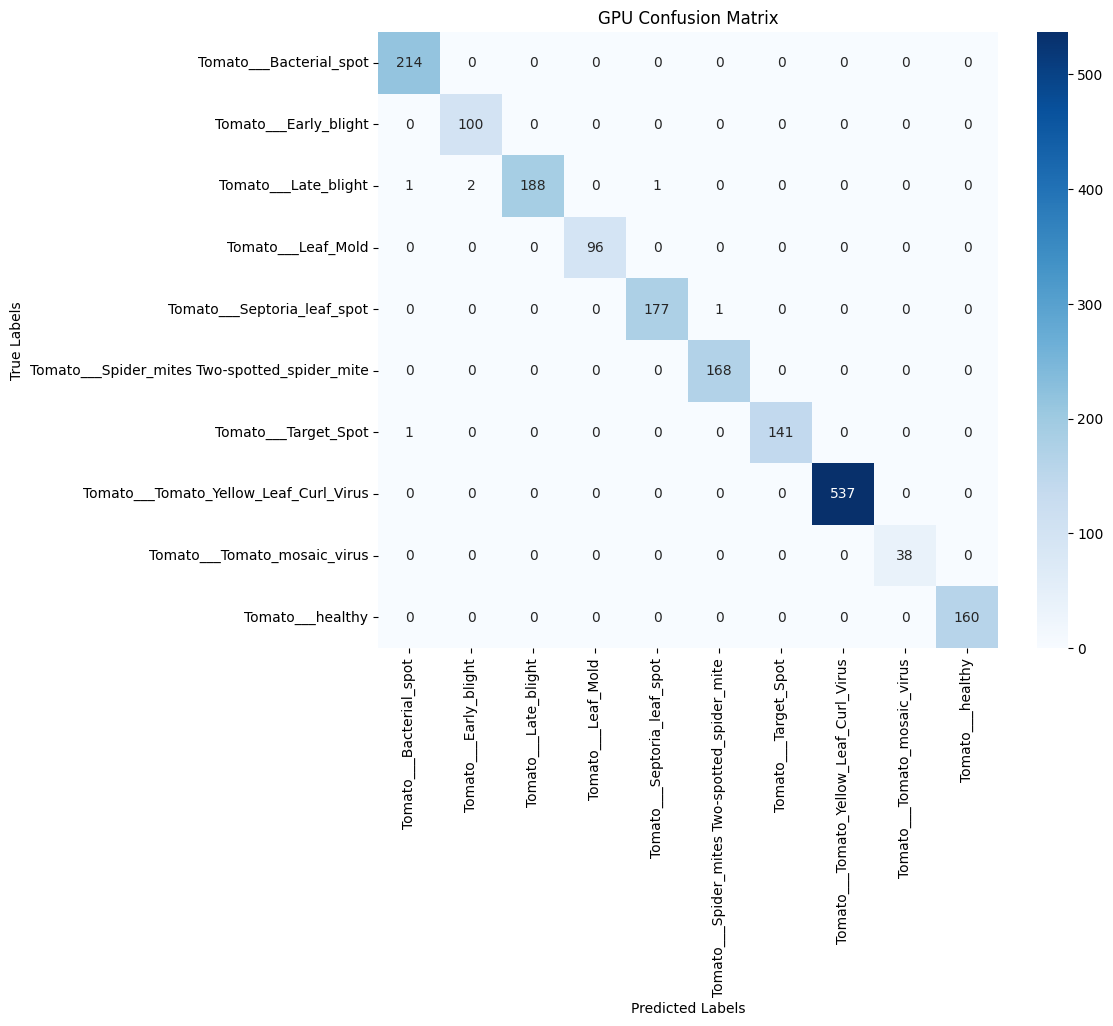

In [13]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchmetrics
import time
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
import seaborn as sns

# Define the test dataset
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"), transform=valid_test_transforms
)
class_names = test_dataset.classes

# Set device to T4 GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define data loader
batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load the trained model onto GPU
num_classes = len(class_names)
model = HPDCNet(num_classes).to(device)
model_path = "/content/best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Metrics on GPU
test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_confusion_matrix = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

def perform_inference(device):
    model.to(device)
    inference_times = []

    # Warm-up run for GPU timing accuracy
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            _ = model(inputs)
            break

    for i in range(5):
        test_accuracy.reset()
        test_precision.reset()
        test_recall.reset()
        test_f1_score.reset()
        test_confusion_matrix.reset()
        all_labels, all_predictions = [], []

        if device.type == "cuda":
            torch.cuda.synchronize()
        start_time = time.time()

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                test_accuracy.update(outputs, labels)
                test_precision.update(outputs, labels)
                test_recall.update(outputs, labels)
                test_f1_score.update(outputs, labels)
                test_confusion_matrix.update(predicted, labels)

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        if device.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.time()

        inference_times.append((end_time - start_time) * 1000)

    avg_inference_time = np.mean(inference_times) / len(test_loader.dataset)
    avg_accuracy = test_accuracy.compute().item()
    avg_precision = test_precision.compute().item()
    avg_recall = test_recall.compute().item()
    avg_f1 = test_f1_score.compute().item()
    cm = test_confusion_matrix.compute().cpu().numpy()

    return avg_accuracy, avg_precision, avg_recall, avg_f1, avg_inference_time, cm, all_labels, all_predictions

# Perform inference on GPU
(
    avg_accuracy_gpu,
    avg_precision_gpu,
    avg_recall_gpu,
    avg_f1_gpu,
    avg_inference_time_gpu,
    cm_gpu,
    labels_gpu,
    preds_gpu,
) = perform_inference(device)

fps_gpu = 1000 / avg_inference_time_gpu
print(f"GPU ({torch.cuda.get_device_name(0)}) Average Test Accuracy: {avg_accuracy_gpu:.4f}")
print(f"GPU Average Test Precision: {avg_precision_gpu:.4f}")
print(f"GPU Average Test Recall: {avg_recall_gpu:.4f}")
print(f"GPU Average Test F1 Score: {avg_f1_gpu:.4f}")
print(f"GPU Average Inference Time per Image: {avg_inference_time_gpu:.6f} ms")
print(f"GPU Frames per Second: {fps_gpu:.2f}")

# Plot Confusion Matrix
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

plot_confusion_matrix(cm_gpu, class_names, "GPU Confusion Matrix")

## 🧪 Visualizing Model Predictions on Sample Test Images

To better understand how the model performs on real data, we selected a set of 20 representative test images—two from each class (when available).

For each image, we performed forward inference and compared the **predicted label** against the **true label**:

- ✅ Correct predictions are shown with **green titles**
- ❌ Incorrect predictions are highlighted in **red**

The images are displayed in a grid layout for quick inspection. This visualization helps:

- Evaluate **class-wise performance**
- Identify **failure patterns**
- Visually inspect prediction **confidence and mistakes**


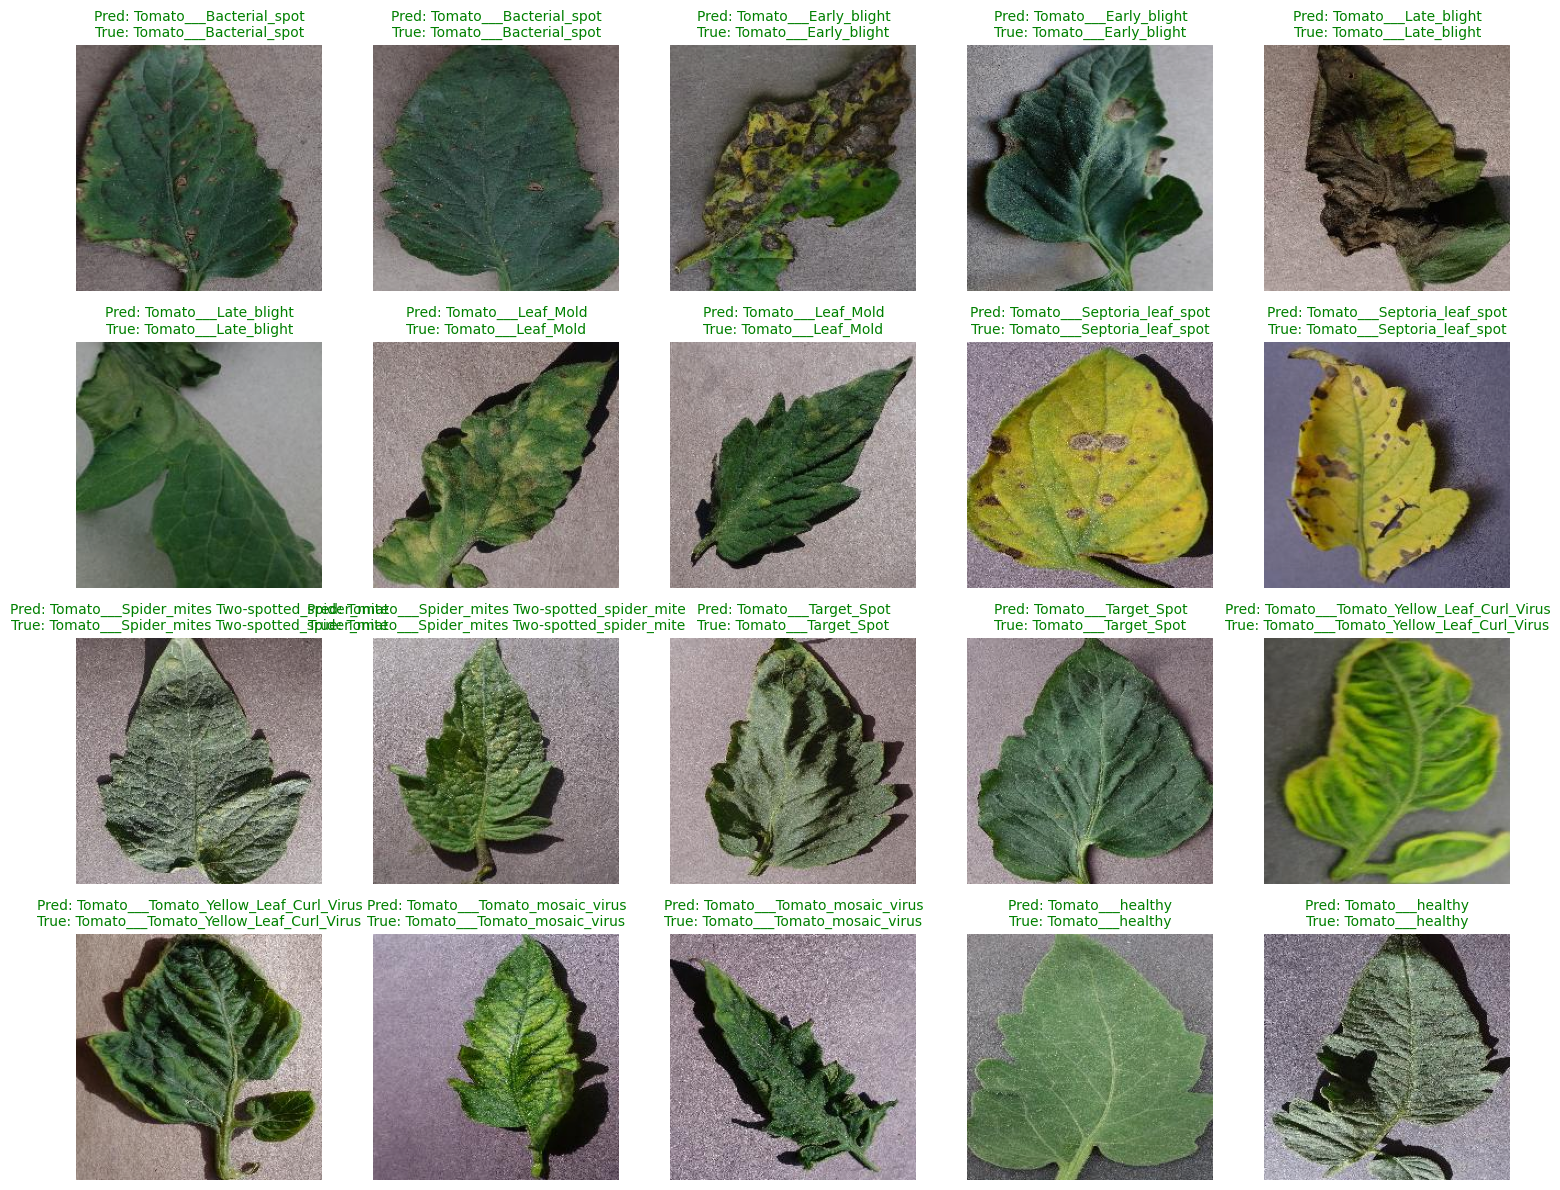

In [14]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inverse transform for displaying standard ImageNet normalized images
inv_transform = transforms.Compose(
    [
        transforms.Normalize(
            mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
            std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
        ),
        transforms.ToPILImage(),
    ]
)

# Collect images and keep on CPU to avoid GPU OOM
all_images = []
all_labels = []

for inputs, labels in test_loader:
    all_images.append(inputs)
    all_labels.append(labels)

all_images = torch.cat(all_images, dim=0)
all_labels = torch.cat(all_labels, dim=0)

num_classes = len(class_names)
class_indices = {i: [] for i in range(num_classes)}

for idx, label in enumerate(all_labels):
    class_indices[label.item()].append(idx)

# Select samples per class evenly
samples_per_class = max(1, 20 // num_classes)
selected_indices = []

for indices in class_indices.values():
    if len(indices) >= samples_per_class:
        selected_indices.extend(random.sample(indices, samples_per_class))
    else:
        selected_indices.extend(indices)

# Fill up to 20 images if needed
if len(selected_indices) < 20:
    remaining_indices = list(set(range(len(all_labels))) - set(selected_indices))
    additional_needed = min(20 - len(selected_indices), len(remaining_indices))
    selected_indices.extend(random.sample(remaining_indices, additional_needed))

# Gather selected samples and send to device
selected_images = all_images[selected_indices].to(device)
selected_labels = all_labels[selected_indices].to(device)

# Perform inference
model = model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(selected_images)
    _, predicted_labels = torch.max(outputs, 1)

# Plot grid
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for idx, ax in zip(range(len(selected_images)), axes.flat):
    img = inv_transform(selected_images[idx].cpu())
    pred_idx = predicted_labels[idx].item()
    true_idx = selected_labels[idx].item()

    color = "green" if pred_idx == true_idx else "red"

    ax.imshow(img)
    ax.set_title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}", color=color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import zipfile
import os
from google.colab import files

# Path to your model file
model_file_path = "/content/best_model.pth"

# Path to save the zip file
zip_file_path = "/content/best_model.zip"

# Create a zip file and add the model file to it
with zipfile.ZipFile(zip_file_path, "w") as zipf:
    zipf.write(model_file_path, os.path.basename(model_file_path))

# Download the zip file to your local machine
files.download(zip_file_path)